**Import libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

**Load and prepare the dataset**

In [2]:
data = fetch_california_housing(as_frame=True)

df = pd.concat(
    [data.data, data.target.rename("HousePrice")],
    axis=1
)

X = df.drop("HousePrice", axis=1)
y = df["HousePrice"]

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


**Train-test split and feature scaling**

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Detect overfitting**

In [4]:
tree = DecisionTreeRegressor(random_state=42)

tree.fit(X_train_scaled, y_train)

train_pred = tree.predict(X_train_scaled)
test_pred = tree.predict(X_test_scaled)

train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))

print("Training RMSE:", train_rmse)
print("Test RMSE:", test_rmse)

Training RMSE: 3.218325866275131e-16
Test RMSE: 0.7028289572288925


**Cross-validation**

In [5]:
tree_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("tree", DecisionTreeRegressor(random_state=42))
])

cv_scores = cross_val_score(
    tree_pipeline,
    X_train,
    y_train,
    scoring="neg_root_mean_squared_error",
    cv=5
)

cv_rmse = -cv_scores.mean()

print("Cross-Validation RMSE:", cv_rmse)

Cross-Validation RMSE: 0.7243182067025009


**Hyperparameter tuning using GridSearchCV**

In [6]:
param_grid = {
    "tree__max_depth": [3, 5, 7, 10],
    "tree__min_samples_split": [2, 5, 10]
}

grid = GridSearchCV(
    tree_pipeline,
    param_grid,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV RMSE:", -grid.best_score_)

Best Parameters: {'tree__max_depth': 10, 'tree__min_samples_split': 10}
Best CV RMSE: 0.6374956796940052


**Evaluate the tuned model**

In [7]:
best_tree = grid.best_estimator_

y_pred = best_tree.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Tuned Decision Tree RMSE:", rmse)
print("Tuned Decision Tree R²:", r2)

Tuned Decision Tree RMSE: 0.6453626634464059
Tuned Decision Tree R²: 0.6821656640892819


**Evaluate the baseline models**

In [8]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)

lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2 = r2_score(y_test, lr_pred)


ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

ridge_pred = ridge.predict(X_test_scaled)

ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_pred))
ridge_r2 = r2_score(y_test, ridge_pred)

**Model comparison table**

In [9]:
results = {
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Tuned Decision Tree"
    ],
    "RMSE": [
        lr_rmse,
        ridge_rmse,
        rmse
    ],
    "R2 Score": [
        lr_r2,
        ridge_r2,
        r2
    ]
}

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="RMSE", ascending=True
).reset_index(drop=True)

results_df.round(3)

,Model,RMSE,R2 Score
0,Tuned Decision Tree,0.645,0.682
1,Ridge Regression,0.746,0.576
2,Linear Regression,0.746,0.576


**Actual vs Predicted visualization**

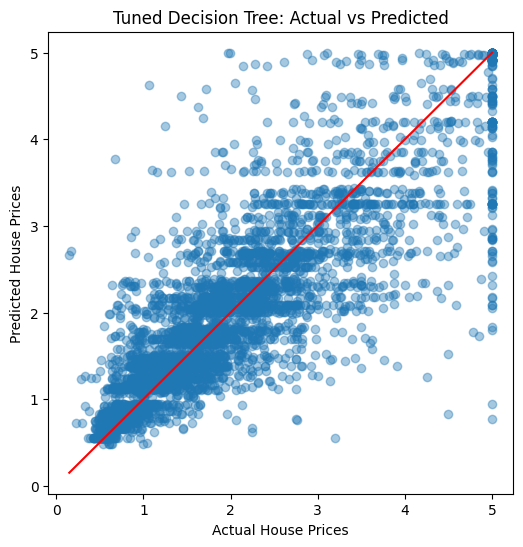

In [10]:
plt.figure(figsize=(6, 6))

plt.scatter(y_test, y_pred, alpha=0.4)

plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title("Tuned Decision Tree: Actual vs Predicted")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)

plt.show()

In [11]:
print("Default Decision Tree")
print("Training RMSE:", train_rmse)
print("Test RMSE:", test_rmse)

print("\nTuned Decision Tree")
print("Best CV RMSE:", -grid.best_score_)
print("Test RMSE:", rmse)
print("Test R²:", r2)

Default Decision Tree
Training RMSE: 3.218325866275131e-16
Test RMSE: 0.7028289572288925

Tuned Decision Tree
Best CV RMSE: 0.6374956796940052
Test RMSE: 0.6453626634464059
Test R²: 0.6821656640892819
